# PG&E Hosting Capacity Calculations

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box, MultiLineString
import matplotlib.pyplot as plt

In [2]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [3]:
# set option to see all data frame columns
pd.set_option('display.max_columns', None)

In [4]:
# Read in circuits
circuits_raw = gpd.read_parquet("../../../../../../capstone/electrigrid/data/utilities/pge_updated/pge.parquet").to_crs("EPSG:4326")

In [5]:
# Read in customer usage data
feeder = gpd.read_file("../../../../../../capstone/electrigrid/data/utilities/pge_shapefiles/FeederDetail.shp")

In [6]:
## Unit conversion --> no longer necessary with kW data
# vars = ['GenCapacity_','GenericPVC', 'GenCapacity_no_OpFlex_kW', , 'LoadCapacity_kW']

# for col in vars:
#     circuits_raw[col] = circuits_raw[col] / 1000

In [7]:
circuits_raw = circuits_raw[['FeederId', 'CSV_LineSection','LoadCapacity_kW', 'GenCapacity_kW', 'GenericPVCapacity_kW', 'GenCapacity_no_OpFlex_kW', 'GenericCapacity_no_OpFlex_kW', 'geometry']]
circuits_raw.head(2)

,FeederId,CSV_LineSection,LoadCapacity_kW,GenCapacity_kW,GenericPVCapacity_kW,GenCapacity_no_OpFlex_kW,GenericCapacity_no_OpFlex_kW,geometry
0,254611104,5724447,NaN,0.0,0.0,0.0,0.0,"MULTILINESTRING ((-120.09424 36.99662, -120.09..."
1,254611104,3485801,0.0,0.0,0.0,0.0,0.0,"MULTILINESTRING ((-120.10806 37.01024, -120.10..."


### Calculate customer usage percentages

In [8]:
# Calculate total customers per feeder
feeder['total'] = feeder['ResCust'] + feeder['ComCust'] + feeder['IndCust'] + feeder['AgrCust'] + feeder['OthCust']

# Percentage of each customer type
feeder['perc_res'] = feeder['ResCust'] / feeder['total'] * 100
feeder['perc_com'] = feeder['ComCust'] / feeder['total'] * 100
feeder['perc_ind'] = feeder['IndCust'] / feeder['total'] * 100
feeder['perc_agr'] = feeder['AgrCust'] / feeder['total'] * 100
feeder['perc_oth'] = feeder['OthCust'] / feeder['total'] * 100

In [9]:
feeder.head(2)

feeder = feeder.rename(columns = {'FeederID':'FeederId'})

In [10]:
# Keep only rows of interest
feeder = feeder[['FeederId','perc_res', 'perc_com', 'perc_ind', 'perc_agr', 'perc_oth']]

### Join customer usage to feeder IDs

In [11]:
circuits = pd.merge(circuits_raw, feeder, on = "FeederId")

In [12]:
circuits.head(2)

,FeederId,CSV_LineSection,LoadCapacity_kW,GenCapacity_kW,GenericPVCapacity_kW,GenCapacity_no_OpFlex_kW,GenericCapacity_no_OpFlex_kW,geometry,perc_res,perc_com,perc_ind,perc_agr,perc_oth
0,254611104,5724447,NaN,0.0,0.0,0.0,0.0,"MULTILINESTRING ((-120.09424 36.99662, -120.09...",76.08802,12.762836,4.303178,6.356968,0.488998
1,254611104,3485801,0.0,0.0,0.0,0.0,0.0,"MULTILINESTRING ((-120.10806 37.01024, -120.10...",76.08802,12.762836,4.303178,6.356968,0.488998


# Calculating Hosting Capacity for a Feederline with Values!

## Step 0: Load in the other necessary data

In [13]:
# PG&E shapefile
utility_ter = gpd.read_file("../../../../../../capstone/electrigrid/data/utilities/IOU_shapefiles.geojson")

# filter to only pge 
pge_shape = utility_ter[utility_ter['Acronym'] == 'PG&E'] 

# check the crs
pge_shape = pge_shape.to_crs('EPSG:4326')

In [14]:
# read in building data
buildings = gpd.read_parquet("../../../../../../capstone/electrigrid/data/zillow_complete_units.parquet").to_crs("EPSG:4326")
buildings = gpd.clip(buildings, pge_shape)

In [15]:
# read in the census tract data
census_tracts = gpd.read_file("../../../../../../capstone/electrigrid/data/census/tl_2025_06_tract/tl_2025_06_tract.shp").to_crs('EPSG:4326')
census_tracts = gpd.clip(census_tracts, pge_shape)

## Step 1: Link the homes to the nearest feederline

Each home gets its electricty from a specific feederline. The nearest neighbor is the method chosen. Then to avoid including homes that are outliers and likely gettin electricity from other sources homes that are further than 1km from their assigned feederline are dropped. 

In order to match the workflow below, I will rename some variables first.

#### Change column names to match other utilites

In [16]:
circuits = circuits.rename(columns = {'FeederId':'circuit_id',
                                        'CSV_LineSection':'segment_id',
                                        'LoadCapacity_kW':'load_cap',
                                        'GenCapacity_no_OpFlex_kW':'gencap',
                                        'GenCapacity_kW':'gencap_opflex',
                                        'GenericCapacity_no_OpFlex_kW':'gencap_pv',
                                        'GenericPVCapacity_kW':'gencap_pv_opflex'})

### Step 1a: Multiply generations by residential customer percentage

In [17]:
for col in ['gencap', 'gencap_pv', 'gencap_opflex', 'gencap_pv_opflex', 'load_cap']:
    circuits[col] = circuits[col] * (circuits['perc_res'] / 100)

In [18]:
# renaming variables :)
clipped = gpd.clip(circuits, pge_shape)
buildings_clipped = buildings
census_clipped = census_tracts

KeyboardInterrupt: 

In [19]:
clipped = circuits
buildings_clipped = buildings
census_clipped = census_tracts

In [ ]:
clipped.head(2)

#### Step 1a: Create line length column

Our data analysis will need length data for each line segment. This value is provided in the SCE data but must be calculated for the SDG&E data. Let's calculate the lengths for each segment of the feederline.

In [20]:
# change the crs to a projected CRS
clipped = clipped.to_crs("EPSG:3310")
buildings_clipped = buildings_clipped.to_crs("EPSG:3310")
census_clipped = census_clipped.to_crs("EPSG:3310")

## create length column in metres
clipped['length_m'] = clipped.length

In [21]:
clipped.head(2)

,circuit_id,segment_id,load_cap,gencap_opflex,gencap_pv_opflex,gencap,gencap_pv,geometry,perc_res,perc_com,perc_ind,perc_agr,perc_oth,length_m
0,254611104,5724447,NaN,0.0,0.0,0.0,0.0,"MULTILINESTRING ((-8375.779 -113354.293, -8375...",76.08802,12.762836,4.303178,6.356968,0.488998,4.577258
1,254611104,3485801,0.0,0.0,0.0,0.0,0.0,"MULTILINESTRING ((-9601.861 -111838.280, -9602...",76.08802,12.762836,4.303178,6.356968,0.488998,82.015817


### Step 1b: Complete join

In [22]:
# index the data
clipped.sindex
buildings_clipped.sindex

# spatial join
buildings_linked = gpd.sjoin_nearest(buildings_clipped, 
                                        clipped, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

### Step 1c: Filter for homes that are less than 1000m away from the nearest feederline
If they are more than 1 km away, we assume they get their power from a different source.

In [23]:
buildings_linked = buildings_linked[buildings_linked['dist_to_line_m'] < 1000]

#### Step 2: Add census tract ID (`geoid`) to each home through spatial join

These tract IDs should be added to the homes dataframes as they are necessary for further calculations. 


In [24]:
#buildings_linked = buildings_linked.drop('index__right', axis = 1)
buildings_linked.head(2)

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,geometry,index__right,circuit_id,segment_id,load_cap,gencap_opflex,gencap_pv_opflex,gencap,gencap_pv,perc_res,perc_com,perc_ind,perc_agr,perc_oth,length_m,dist_to_line_m
1732349,Single,1976.0,3.0,others,others,I,1.0,139769.0,living,1440.0,1536697.0,06029003222,15,PGE/SCE,RR103,POINT (90277.955 -312644.819),1261678,253481103,3407284,124.567568,0.0,0.0,0.0,0.0,29.72973,12.972973,1.621622,55.675676,0.0,76.216486,70.375476
1732346,Single,1987.0,2.0,fossil,room,I,1.0,271458.0,living,1034.0,1536693.0,06029003222,15,PGE/SCE,RR103,POINT (90245.993 -312459.692),102593,253481103,5243587,121.297297,0.0,0.0,0.0,0.0,29.72973,12.972973,1.621622,55.675676,0.0,57.002959,88.830607


In [25]:
# rename GEOID column
buildings_linked = buildings_linked.rename(columns = {'GEOID':'geoid',
                                                     'unit':'total_units'}) # remove with new data
census_clipped = census_clipped.rename(columns = {'GEOID':'geoid'})

In [26]:
# make sure the dataframes have the same crs before performing spatial computations
assert census_clipped.crs == buildings_linked.crs

In [27]:
buildings_linked = buildings_linked.drop(columns=['geoid', 'index_right'], errors='ignore')
buildings_linked = gpd.sjoin(buildings_linked, census_clipped[['geoid', 'geometry']], how="left", predicate="within")

#### Some homes may intersect two census tracts

We assign homes to the tract that contains more of the house's area, in order to avoid duplicates

In [28]:
# how many homes were not assigned to any tract?
no_tract = buildings_linked['index_right'].isna().sum()

In [ ]:
# how many buildings were duplicated because they split census tracts?
buildings_linked.duplicated().sum()

In [30]:
## FOR BUILDINGS INTERSECTING MORE THAN ONE CENSUS TRACT CALCULATE WHICH TRACT IT INTERSECTS MORE
# change the crs to a projected crs
buildings_linked = buildings_linked.to_crs("EPSG:6933")
census_clipped = census_clipped.to_crs("EPSG:6933")

# filter out buildings that don't match a census tract
buildings_linked = buildings_linked[buildings_linked["index_right"].notna()]

# calculate intersection area for each building-parcel pair
buildings_linked["intersection_area"] = (
    buildings_linked.geometry.values
    .intersection(census_clipped.loc[buildings_linked["index_right"]].geometry.values).area)

# keep only the parcel with the largest overlap per building
buildings_linked = (
    buildings_linked
    .sort_values("intersection_area", ascending=False)
    .loc[~buildings_linked.index.duplicated(keep="first")]
    .drop(columns="intersection_area"))

# drop the unnecessary columns
buildings_linked = buildings_linked.drop(columns = ['index_right'])
buildings_linked = buildings_linked.rename(columns = {'unit_right': 'total_unit'})
buildings_linked = buildings_linked.rename(columns = {'unit_right': 'total_unit'})

In [ ]:
# duplicates now?
buildings_linked.duplicated().sum()

In [ ]:
# duplicates of original building df?
buildings_clipped.duplicated().sum()

In [ ]:
Our join removed some of the original building duplicates!

#### Step 3: Calculate the number of homes in each census tract

The number of homes in each census tract is used further in the calculation. Save it as a new column in the homes dataframes. 

In [32]:
buildings_linked['homes_per_tract'] = buildings_linked.groupby('geoid')['total_units'].transform('sum')

#### Step 4: Calculate the maximum ICA generation capacity for each circuit

Generation capacity varies across the circuit. The maximum is utilized in calculating the hosting capacity. Add the new data to the data frame as a column.


In [33]:
# save the max ICA generation capacity by the circuit
buildings_linked['max_gen_circuit'] = buildings_linked.groupby('circuit_id')['gencap'].transform('max')

#### Step 5: Calculate the percentage of the length of each segment relative to the entire feederline

First calculate the length of the whole circuit. Then divide each segment’s length by the length of the whole circuit. Save to the dataframe in a new column. 


In [34]:
# calculate the percentage of the length of each segment relative to the whole dataframe
clipped['percent_length'] = clipped['length_m'] / clipped.groupby('circuit_id')['length_m'].transform('sum')

In [35]:
buildings_linked.head()

,type,year,room,heat,cool,own,total_units,value,sqft_type,sqft,ID,p_ID,area,code,geometry,index__right,circuit_id,segment_id,load_cap,gencap_opflex,gencap_pv_opflex,gencap,gencap_pv,perc_res,perc_com,perc_ind,perc_agr,perc_oth,length_m,dist_to_line_m,geoid,homes_per_tract,max_gen_circuit
1732349,Single,1976.0,3.0,others,others,I,1.0,139769.0,living,1440.0,1536697.0,15,PGE/SCE,RR103,POINT (-11482611.645 4219512.016),1261678,253481103,3407284,124.567568,0.0,0.0,0.0,0.0,29.729730,12.972973,1.621622,55.675676,0.0,76.216486,70.375476,06029003222,589.0,0.0
6136048,Single,1967.0,NaN,elec,None,O,1.0,131174.0,living,1144.0,10536787.0,422,PGE/SCE,RR101,POINT (-11520233.619 4360215.904),395074,252341101,4010081,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,63.785889,62.433595,06107000401,1569.0,0.0
6137264,Single,2007.0,3.0,fossil,central,None,1.0,258286.0,living,2067.0,10538104.0,422,PGE/SCE,RR101,POINT (-11520913.562 4360184.084),138356,252341101,3593567,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,119.497822,18.741422,06107000401,1569.0,0.0
6137265,Single,2006.0,4.0,fossil,central,None,1.0,328663.0,living,2780.0,10538105.0,422,PGE/SCE,RR101,POINT (-11520955.437 4360185.114),140607,252341101,4220737,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,236.641906,14.757015,06107000401,1569.0,0.0
6137266,Single,2011.0,4.0,fossil,central,O,1.0,232897.0,living,2000.0,10538106.0,422,PGE/SCE,RR101,POINT (-11520976.375 4360185.629),140607,252341101,4220737,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,236.641906,17.477181,06107000401,1569.0,0.0


#### Step 6:  Calculate the number of homes connected to each segment



In [36]:
# aggregate number of homes that connect to each segment
buildings_linked['homes_per_segment'] = buildings_linked.groupby('segment_id')['total_units'].transform('sum')

#### Step 7:  Calculate the total number of homes connected to the whole circuit

In [37]:
# aggregate number of homes that connect to each circuit
buildings_linked['homes_per_circuit'] = buildings_linked.groupby('circuit_id')['circuit_id'].transform('count')

#### Step 8:  Calculate the percent of homes connected to each segment relative to all of the homes connected to the entire circuit

In [38]:
buildings_linked['percent_homes_circuit'] = buildings_linked['homes_per_segment'] / buildings_linked['homes_per_circuit']

#### Step 9:  Calculate the weighted generation capacity for each segment of the feederline

Multiply the total generation capacity of the segment by the percent of homes connected to each segment. This calculation undercounts the total generation capacity.

In [39]:
# weighted generation capacity calculations
buildings_linked['weighted_gencap'] = buildings_linked['gencap'] * buildings_linked['percent_homes_circuit']

#### Step 10:  Calculate the number of homes located within each census tract for each circuit


In [40]:
buildings_linked['homes_per_tract_circuit'] = buildings_linked.groupby(['circuit_id', 'geoid'])['circuit_id'].transform('count')

#### Step 11:  Calculate the weighted household max hosting capacity for each circuit tract combo (Brockway Eq 8)

Divide the number of homes located within each census tract for each circuit by the total number of homes connected to the whole circuit and multiply that value by the max generation capacity report for each circuit tract combo.


In [41]:
# calculate the max generation capacity for the circuit tract combo
buildings_linked['max_gen_tract_circuit'] = buildings_linked.groupby(['circuit_id', 'geoid'])['gencap'].transform('max')

In [42]:
# calculate the weighted household max hosting capacity for each circuit tract combo
buildings_linked['weighted_max_gen_circuit_tract'] = (buildings_linked['homes_per_tract_circuit'] / buildings_linked['homes_per_circuit']) * buildings_linked['max_gen_tract_circuit']

####  Step 12:  Normalize the generation capacity for each circuit polygon combo (Brockway Eq 9)

We normalize the generation capacity because weighting the generation capacity under counts the total number of MW available. 

Divide the maximum hosting capacity from anywhere on the given circuit by the  weighted household max hosting capacity for each circuit tract combo, and then multiply by the  weighted household max hosting capacity for each circuit tract combo. 

Weighted max generation per circuit tract is aggregated to just each circuit in this case.

In [43]:
buildings_linked['normalized_gen'] = (buildings_linked['max_gen_circuit'] / buildings_linked.groupby('circuit_id')['weighted_max_gen_circuit_tract'].transform('sum')) * buildings_linked['weighted_max_gen_circuit_tract']

#### Step 13:  Adjust the normalized values to the maximum generation (Brockway Eq 10)

For each normalized value for the circuit polygon combos, ensure they are not over the original maximum value for that circuit polygon. Adjust down to the max where necessary.


In [44]:
buildings_linked['normalized_gen_adj'] = np.where(
    buildings_linked['normalized_gen'] > buildings_linked['max_gen_circuit'],
    buildings_linked['max_gen_circuit'],
    buildings_linked['normalized_gen'])

#### Step 14: Calculate the household hosting capacity (Brockway Eq 11)

Divide the generation capacity for the circuit tracts by the number of homes connected in that circuit tract.

In [45]:
buildings_linked['hh_gencap'] = (buildings_linked['normalized_gen_adj'] / buildings_linked['homes_per_tract_circuit'])

In [46]:
print(buildings_linked.columns.tolist())

['type', 'year', 'room', 'heat', 'cool', 'own', 'total_units', 'value', 'sqft_type', 'sqft', 'ID', 'p_ID', 'area', 'code', 'geometry', 'index__right', 'circuit_id', 'segment_id', 'load_cap', 'gencap_opflex', 'gencap_pv_opflex', 'gencap', 'gencap_pv', 'perc_res', 'perc_com', 'perc_ind', 'perc_agr', 'perc_oth', 'length_m', 'dist_to_line_m', 'geoid', 'homes_per_tract', 'max_gen_circuit', 'homes_per_segment', 'homes_per_circuit', 'percent_homes_circuit', 'weighted_gencap', 'homes_per_tract_circuit', 'max_gen_tract_circuit', 'weighted_max_gen_circuit_tract', 'normalized_gen', 'normalized_gen_adj', 'hh_gencap']


## Steps 4-14 on the rest of the generation variables

In [47]:
# Run the Steps 4-14 pipeline for each remaining cap column
for col in ['gencap_pv', 'gencap_opflex', 'gencap_pv_opflex', 'load_cap']:

    # Step 4: max generation capacity by circuit
    buildings_linked[f'max_{col}_circuit'] = buildings_linked.groupby('circuit_id')[col].transform('max')

    # Step 9: weighted generation capacity
    buildings_linked[f'weighted_{col}'] = buildings_linked[col] * buildings_linked['percent_homes_circuit']

    # Step 11a: max generation capacity per circuit/tract combo
    buildings_linked[f'max_{col}_circuit_tract'] = buildings_linked.groupby(['circuit_id', 'geoid'])[col].transform('max')

    # Step 11b: weighted household max hosting capacity per circuit/tract combo
    buildings_linked[f'weighted_max_{col}_circuit_tract'] = (
        buildings_linked['homes_per_tract_circuit'] / buildings_linked['homes_per_circuit']
    ) * buildings_linked[f'max_{col}_circuit_tract']

    # Step 12: normalize generation capacity
    buildings_linked[f'normalized_{col}'] = (
        buildings_linked[f'max_{col}_circuit'] / buildings_linked[f'weighted_max_{col}_circuit_tract']
    ) * buildings_linked[f'weighted_max_{col}_circuit_tract']

    # Step 13: adjust normalized values down to circuit/tract max where needed
    buildings_linked[f'normalized_{col}_adj'] = np.where(
        buildings_linked[f'normalized_{col}'] > buildings_linked[f'max_{col}_circuit_tract'],
        buildings_linked[f'max_{col}_circuit_tract'],
        buildings_linked[f'normalized_{col}'])

    # Step 14: individual home hosting capacity in KW
    buildings_linked[f'hh_{col}'] = (
        buildings_linked[f'normalized_{col}_adj'] / buildings_linked['homes_per_tract_circuit'])


### Step 15: Add load capacity (Brockway Eq 12)

In [48]:
# Add load capacity to generation capacity variables
for col in ['gencap', 'gencap_pv', 'gencap_opflex', 'gencap_pv_opflex']:
    buildings_linked[f'hh_{col}'] = buildings_linked[f'hh_{col}'] + buildings_linked[f'hh_load_cap']

In [49]:
buildings_linked.head()

,type,year,room,heat,cool,own,total_units,value,sqft_type,sqft,ID,p_ID,area,code,geometry,index__right,circuit_id,segment_id,load_cap,gencap_opflex,gencap_pv_opflex,gencap,gencap_pv,perc_res,perc_com,perc_ind,perc_agr,perc_oth,length_m,dist_to_line_m,geoid,homes_per_tract,max_gen_circuit,homes_per_segment,homes_per_circuit,percent_homes_circuit,weighted_gencap,homes_per_tract_circuit,max_gen_tract_circuit,weighted_max_gen_circuit_tract,normalized_gen,normalized_gen_adj,hh_gencap,max_gencap_pv_circuit,weighted_gencap_pv,max_gencap_pv_circuit_tract,weighted_max_gencap_pv_circuit_tract,normalized_gencap_pv,normalized_gencap_pv_adj,hh_gencap_pv,max_gencap_opflex_circuit,weighted_gencap_opflex,max_gencap_opflex_circuit_tract,weighted_max_gencap_opflex_circuit_tract,normalized_gencap_opflex,normalized_gencap_opflex_adj,hh_gencap_opflex,max_gencap_pv_opflex_circuit,weighted_gencap_pv_opflex,max_gencap_pv_opflex_circuit_tract,weighted_max_gencap_pv_opflex_circuit_tract,normalized_gencap_pv_opflex,normalized_gencap_pv_opflex_adj,hh_gencap_pv_opflex,max_load_cap_circuit,weighted_load_cap,max_load_cap_circuit_tract,weighted_max_load_cap_circuit_tract,normalized_load_cap,normalized_load_cap_adj,hh_load_cap
1732349,Single,1976.0,3.0,others,others,I,1.0,139769.0,living,1440.0,1536697.0,15,PGE/SCE,RR103,POINT (-11482611.645 4219512.016),1261678,253481103,3407284,124.567568,0.0,0.0,0.0,0.0,29.729730,12.972973,1.621622,55.675676,0.0,76.216486,70.375476,06029003222,589.0,0.0,2.0,27,0.074074,0.0,27,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,162.324324,9.227227,162.324324,162.324324,162.324324,162.324324,6012.012012
6136048,Single,1967.0,NaN,elec,None,O,1.0,131174.0,living,1144.0,10536787.0,422,PGE/SCE,RR101,POINT (-11520233.619 4360215.904),395074,252341101,4010081,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,63.785889,62.433595,06107000401,1569.0,0.0,7.0,1585,0.004416,0.0,848,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
6137264,Single,2007.0,3.0,fossil,central,None,1.0,258286.0,living,2067.0,10538104.0,422,PGE/SCE,RR101,POINT (-11520913.562 4360184.084),138356,252341101,3593567,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,119.497822,18.741422,06107000401,1569.0,0.0,4.0,1585,0.002524,0.0,848,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
6137265,Single,2006.0,4.0,fossil,central,None,1.0,328663.0,living,2780.0,10538105.0,422,PGE/SCE,RR101,POINT (-11520955.437 4360185.114),140607,252341101,4220737,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,236.641906,14.757015,06107000401,1569.0,0.0,23.0,1585,0.014511,0.0,848,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
6137266,Single,2011.0,4.0,fossil,central,O,1.0,232897.0,living,2000.0,10538106.0,422,PGE/SCE,RR101,POINT (-11520976.375 4360185.629),140607,252341101,4220737,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,236.641906,17.477181,06107000401,1569.0,0.0,23.0,1585,0.014511,0.0,848,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN


In [50]:
buildings_linked['hh_load_cap'].describe()

count    2.593055e+06
mean     8.144122e+03
std      3.870989e+04
min      6.547437e-01
25%      1.473740e+03
50%      3.502621e+03
75%      7.394930e+03
max      1.134941e+07
Name: hh_load_cap, dtype: float64

In [51]:
buildings_linked['hh_gencap_opflex'].describe()

count    1.136684e+06
mean     1.214350e+04
std      5.131919e+04
min      7.170795e+01
25%      2.817138e+03
50%      5.318648e+03
75%      1.073395e+04
max      1.184357e+07
Name: hh_gencap_opflex, dtype: float64

<Axes: ylabel='Frequency'>

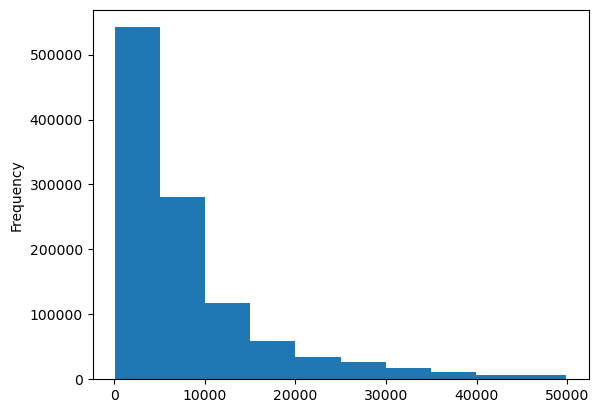

In [52]:
buildings_linked[buildings_linked['hh_gencap_opflex'] < 50000]['hh_gencap_opflex'].plot(kind = "hist")

<Axes: ylabel='Frequency'>

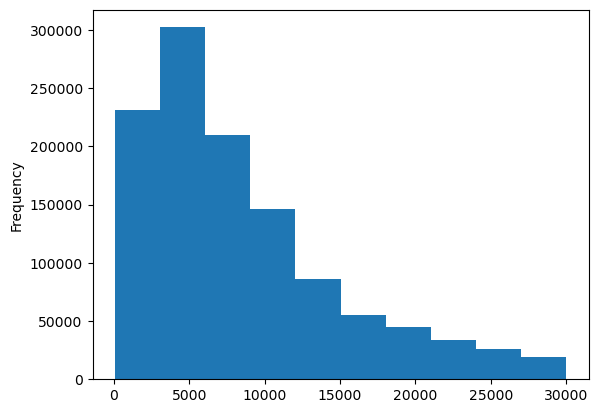

In [53]:
buildings_linked[buildings_linked['hh_gencap_pv'] < 30000]['hh_gencap_pv'].plot(kind = "hist")

In [56]:
buildings_linked['hh_gencap_pv'] = buildings_linked['hh_gencap_pv'].fillna(0)
buildings_linked['hh_gencap_pv'] / 1000.plot(kind = "hist")

SyntaxError: invalid decimal literal (293121275.py, line 2)

In [57]:
buildings_linked['hh_gencap_pv_kw'] = buildings_linked['hh_gencap_pv'] / 1000

<Axes: ylabel='Frequency'>

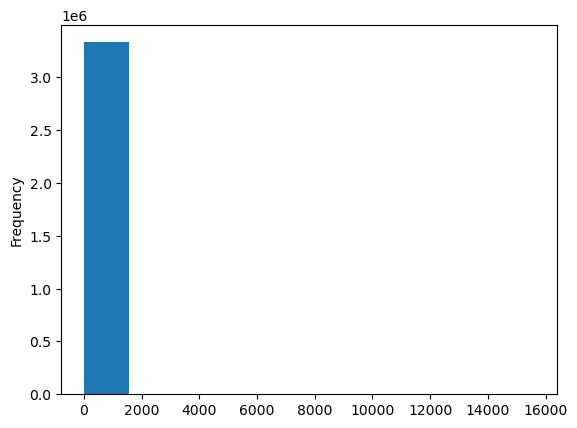

In [58]:
buildings_linked['hh_gencap_pv_kw'].plot(kind = "hist")

<Axes: ylabel='Frequency'>

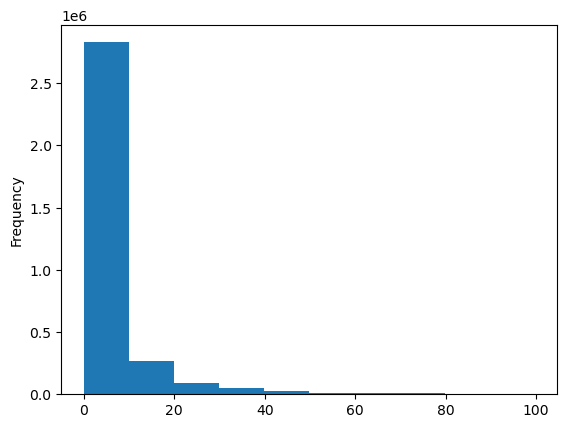

In [63]:
buildings_linked[buildings_linked['hh_gencap_pv_kw'] < 100]['hh_gencap_pv_kw'].plot(kind = "hist")

In [64]:
buildings_linked['gencap_opflex'].describe()

count    3.289832e+06
mean     1.393289e+02
std      3.790683e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      6.891808e+01
max      6.515673e+03
Name: gencap_opflex, dtype: float64

In [65]:
buildings_linked.head()

,type,year,room,heat,cool,own,total_units,value,sqft_type,sqft,ID,p_ID,area,code,geometry,index__right,circuit_id,segment_id,load_cap,gencap_opflex,gencap_pv_opflex,gencap,gencap_pv,perc_res,perc_com,perc_ind,perc_agr,perc_oth,length_m,dist_to_line_m,geoid,homes_per_tract,max_gen_circuit,homes_per_segment,homes_per_circuit,percent_homes_circuit,weighted_gencap,homes_per_tract_circuit,max_gen_tract_circuit,weighted_max_gen_circuit_tract,normalized_gen,normalized_gen_adj,hh_gencap,max_gencap_pv_circuit,weighted_gencap_pv,max_gencap_pv_circuit_tract,weighted_max_gencap_pv_circuit_tract,normalized_gencap_pv,normalized_gencap_pv_adj,hh_gencap_pv,max_gencap_opflex_circuit,weighted_gencap_opflex,max_gencap_opflex_circuit_tract,weighted_max_gencap_opflex_circuit_tract,normalized_gencap_opflex,normalized_gencap_opflex_adj,hh_gencap_opflex,max_gencap_pv_opflex_circuit,weighted_gencap_pv_opflex,max_gencap_pv_opflex_circuit_tract,weighted_max_gencap_pv_opflex_circuit_tract,normalized_gencap_pv_opflex,normalized_gencap_pv_opflex_adj,hh_gencap_pv_opflex,max_load_cap_circuit,weighted_load_cap,max_load_cap_circuit_tract,weighted_max_load_cap_circuit_tract,normalized_load_cap,normalized_load_cap_adj,hh_load_cap,hh_gencap_pv_kw
1732349,Single,1976.0,3.0,others,others,I,1.0,139769.0,living,1440.0,1536697.0,15,PGE/SCE,RR103,POINT (-11482611.645 4219512.016),1261678,253481103,3407284,124.567568,0.0,0.0,0.0,0.0,29.729730,12.972973,1.621622,55.675676,0.0,76.216486,70.375476,06029003222,589.0,0.0,2.0,27,0.074074,0.0,27,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,162.324324,9.227227,162.324324,162.324324,162.324324,162.324324,6012.012012,0.0
6136048,Single,1967.0,NaN,elec,None,O,1.0,131174.0,living,1144.0,10536787.0,422,PGE/SCE,RR101,POINT (-11520233.619 4360215.904),395074,252341101,4010081,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,63.785889,62.433595,06107000401,1569.0,0.0,7.0,1585,0.004416,0.0,848,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.0
6137264,Single,2007.0,3.0,fossil,central,None,1.0,258286.0,living,2067.0,10538104.0,422,PGE/SCE,RR101,POINT (-11520913.562 4360184.084),138356,252341101,3593567,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,119.497822,18.741422,06107000401,1569.0,0.0,4.0,1585,0.002524,0.0,848,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.0
6137265,Single,2006.0,4.0,fossil,central,None,1.0,328663.0,living,2780.0,10538105.0,422,PGE/SCE,RR101,POINT (-11520955.437 4360185.114),140607,252341101,4220737,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,236.641906,14.757015,06107000401,1569.0,0.0,23.0,1585,0.014511,0.0,848,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.0
6137266,Single,2011.0,4.0,fossil,central,O,1.0,232897.0,living,2000.0,10538106.0,422,PGE/SCE,RR101,POINT (-11520976.375 4360185.629),140607,252341101,4220737,0.000000,0.0,0.0,0.0,0.0,90.089739,4.838080,1.092470,3.979711,0.0,236.641906,17.477181,06107000401,1569.0,0.0,23.0,1585,0.014511,0.0,848,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.0


In [66]:
buildings_linked.to_parquet("pge_prelim.parquet")